In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import time
import numpy as np
import random
import fractions

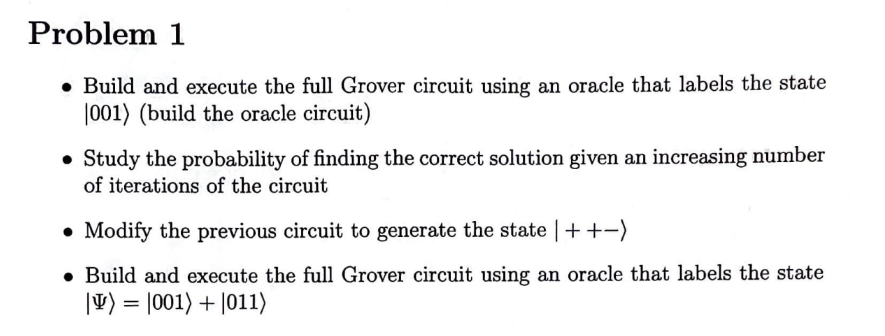
Full Grover circuit using an oracle that labels the state |001>. 

In [8]:
n_bits = 3
query_register = list(range(n_bits))
aux = [n_bits]
all_wires = query_register + aux
dev = qml.device("default.qubit", wires=all_wires)

def hadamard_transform(my_wires):
    """Apply the Hadamard transform on a given set of wires.

    Args:
        my_wires (list[int]): A list of wires on which the Hadamard transform will act.
    """
    for wire in my_wires:
        qml.Hadamard(wires=wire)



@qml.qnode(dev)
def grover_circuit(combo):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    # APPLY GROVER ITERATION
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)

    qml.MultiControlledX(wires=query_register + aux, control_values=combo)

    hadamard_transform(query_register)
    qml.MultiControlledX(wires=query_register + aux, control_values=[0] * len(query_register))
    hadamard_transform(query_register)
    
    return qml.probs(wires=query_register)


print('Probability of measuring |001> after 1 iteration of Grover:', max(grover_circuit([0,0,1])))





Probability of measuring |001> after 1 iteration of Grover: 0.7812499999999989


Probability of finding given an increasing number of iterations of the circuit.

0.12499999999999992
0.7812499999999989
0.9453124999999976
0.33007812499999895
0.14111328124999936
0.547973632812497
0.9997863769531184
0.5769729614257767
0.14007759094238165
0.3028912544250459
0.9312659502029316
0.8049252331256771
0.14496535807847785
0.12766912765800784
0.7566136685199918


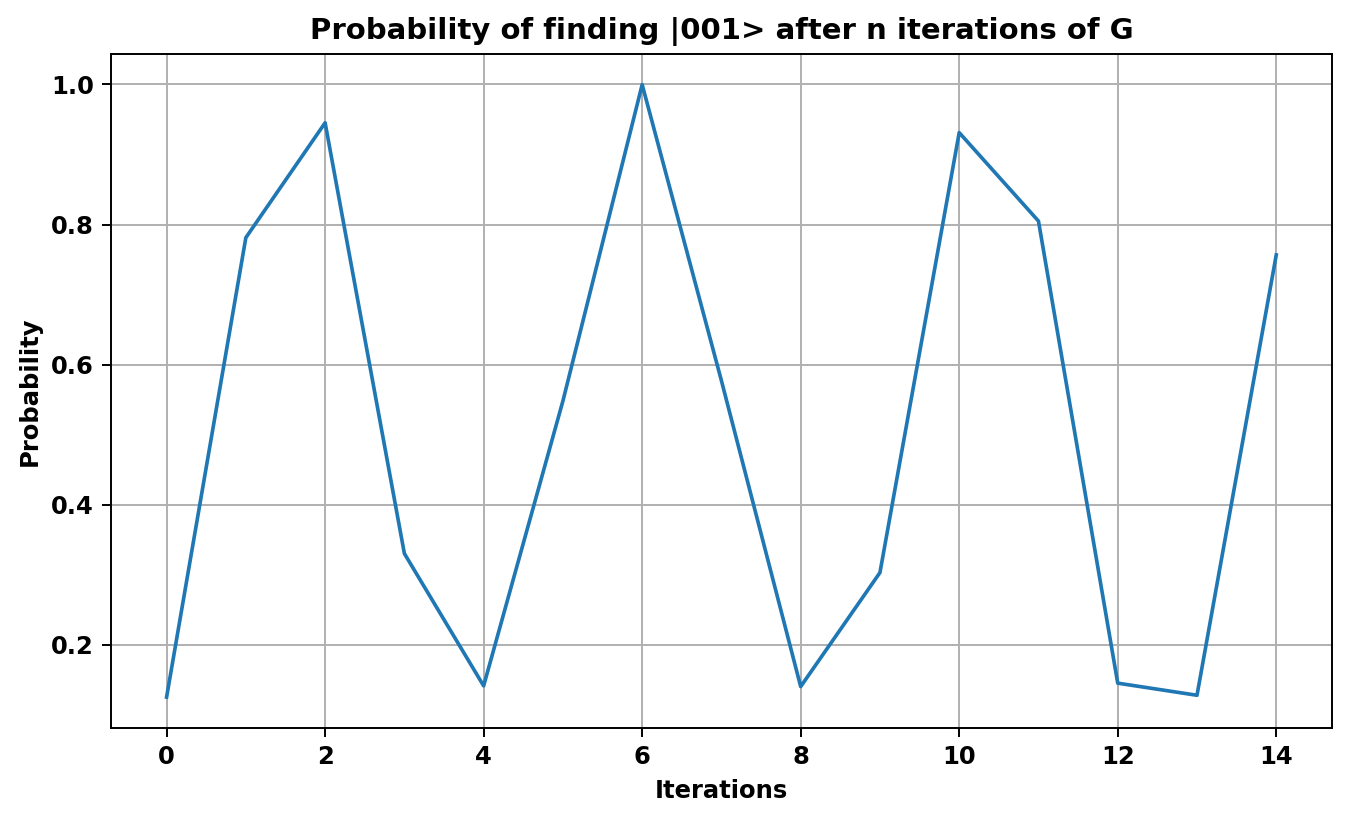

In [9]:

@qml.qnode(dev)
def grover_circuit_n(combo, n_steps):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    # APPLY GROVER ITERATION
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)

    for _ in range(n_steps):
        qml.MultiControlledX(wires=query_register + aux, control_values=combo)
        hadamard_transform(query_register)
        qml.MultiControlledX(wires=query_register + aux, control_values=[0] * len(query_register))
        hadamard_transform(query_register)
    
    return qml.probs(wires=query_register)

points=[]

for i in range(15):
    points.append(max(grover_circuit_n([0,0,1],i)))
    print(points[i])

plt.figure(figsize=(9,5),dpi=175)
plt.plot(points)
plt.title('Probability of finding |001> after n iterations of G')
plt.xlabel('Iterations')
plt.ylabel('Probability')
plt.grid(True)

Modify the previous circuit to generate the state |++->

In [10]:
@qml.qnode(dev)
def grover_circuit_n(combo, n_steps):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    # APPLY GROVER ITERATION
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)

    for _ in range(n_steps):
        qml.MultiControlledX(wires=query_register + aux, control_values=combo)
        hadamard_transform(query_register)
        qml.MultiControlledX(wires=query_register + aux, control_values=[0] * len(query_register))
        hadamard_transform(query_register)
    
    # We know that up until here, for 2 steps we generate the state |001>(+ancilla) with really high probability. If we now apply Hadamard on the 3 first
    # qubits, we will generate |++->(+ancilla).
    
    hadamard_transform(query_register)  
    
    return qml.probs(wires=query_register)

print(grover_circuit_n([0,0,1],2))

[0.015625 0.140625 0.140625 0.140625 0.140625 0.140625 0.140625 0.140625]


Grover circuit that labels the state |001>+|011> is basically labeling both states.

In [11]:
@qml.qnode(dev)
def grover_circuit_multi(combos):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    # APPLY GROVER ITERATION
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)
    
    for combo in combos:
        qml.MultiControlledX(wires=query_register + aux, control_values=combo)
    hadamard_transform(query_register)
    qml.MultiControlledX(wires=query_register + aux, control_values=[0] * len(query_register))
    hadamard_transform(query_register)
    
    return qml.probs(wires=query_register)

combos=[[0,0,1],[0,1,1]]
print(grover_circuit_multi(combos))

[0.  0.5 0.  0.5 0.  0.  0.  0. ]


## Problem 2
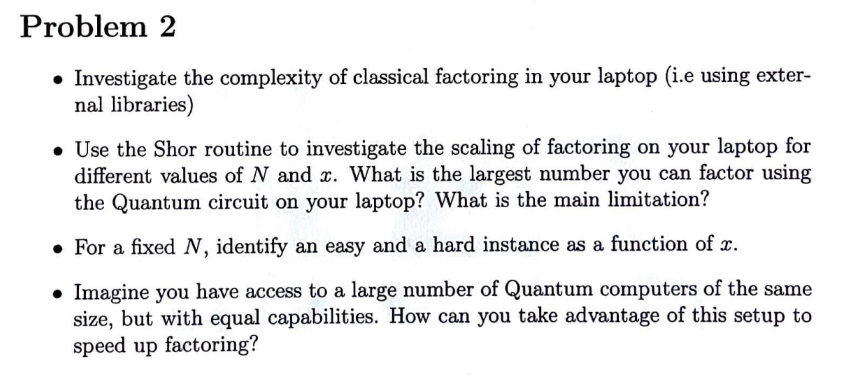
Exploring factoring with other libraries.

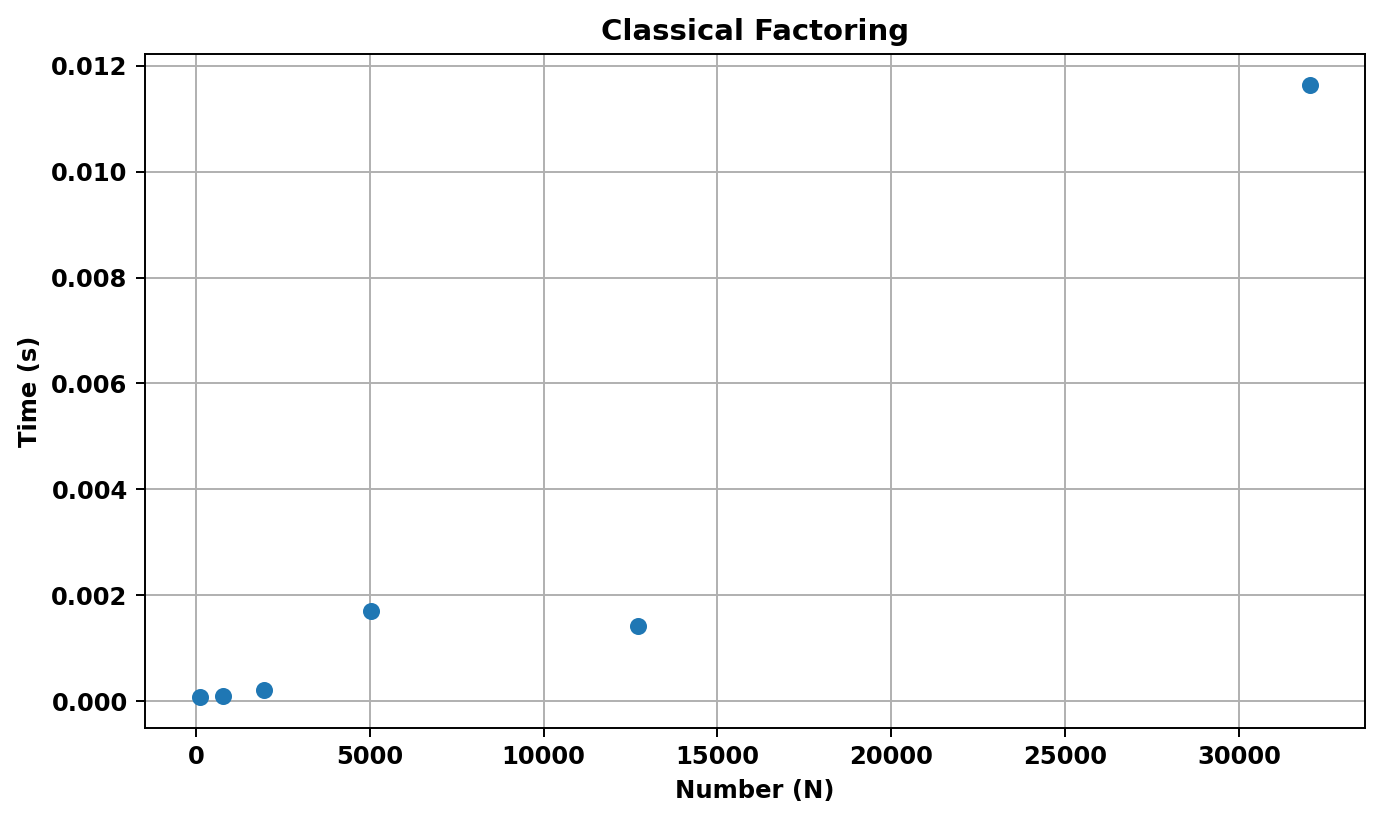

In [ ]:
def nontrivial_square_root(m):
    """Return the first nontrivial square root modulo m.

    Args:
        m (int): modulus for which want to find the nontrivial square root

    Returns:
        int: the first nontrivial square root of m
    """

    for i in range(2, m):
        if (i**2) % m == 1:
            return i
    return -1





def factorization(N):
    """Return the factors of N.

    Args:
        N (int): number we want to factor.

    Returns:
        array[int]: [p,q] factors of N.
    """
    
    nt_sqrt=nontrivial_square_root(N)
    p=np.gcd(N, nt_sqrt + 1)
    q=np.gcd(N, nt_sqrt - 1)
    return p, q
    


p=[11, 71, 179]
numbers=[]
times=[]
for i in range(len(p)):
    for j in range(i,len(p)):
        N=p[i]*p[j]
        numbers.append(N)
        start_time=time.time()
        factorization(N)
        end_time=time.time()
        times.append(end_time-start_time)

plt.figure(figsize=(9,5),dpi=175)
plt.plot(numbers, times, 'o')
plt.xlabel('Number (N)')
plt.ylabel('Time (s)')
plt.title('Classical Factoring')
plt.grid(True)
plt.show()
        

Now using Shor.

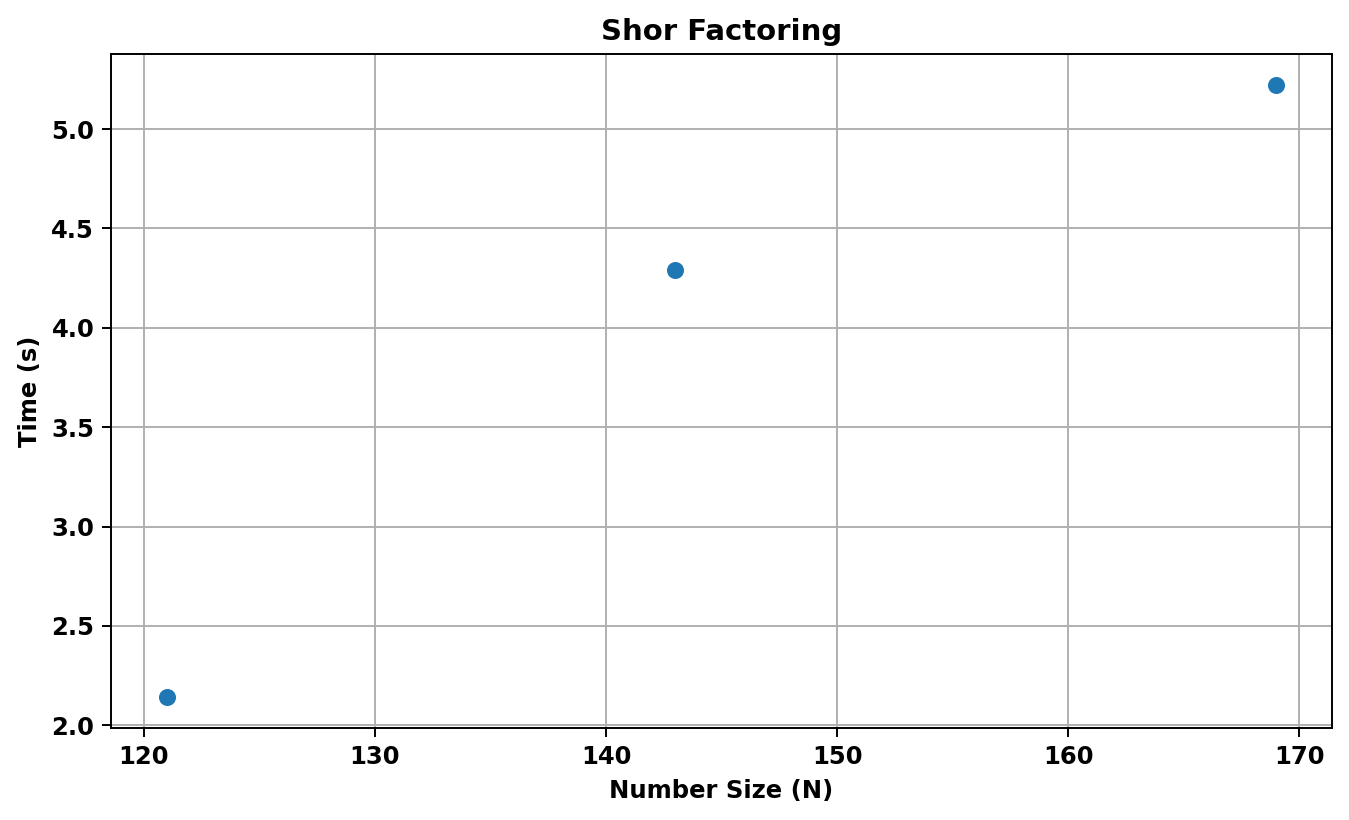

In [13]:
def is_coprime(a, N):
    """Determine if two numbers are coprime.

    Args:
        a (int): First number to check if is coprime with the other.
        N (int): Second number to check if is coprime with the other.

    Returns:
        bool: True if they are coprime numbers, False otherwise.
    """

    if np.gcd(a,N)==1:
        return True
    return False


def is_odd(r):
    """Determine if a number is odd.

    Args:
        r (int): Integer to check if is an odd number.

    Returns:
        bool: True if it is odd, False otherwise.
    """

    if r % 2 == 1: 
        return True
    return False


def is_not_one(x, N):
    """Determine if x is not +- 1 modulo N.

    Args:
        N (int): Modulus of the equivalence.
        x (int): Integer to check if it is different from +-1 modulo N.

    Returns:
        bool: True if it is different, False otherwise.
    """

    if x % N != 1 and x % N != N - 1: 
        return True
    return False


def get_matrix_a_mod_N(a, N, n_target_wires):
    """Builds the Unitary matrix for f(x) = a*x mod N"""
    dim = 2**n_target_wires
    matrix = np.zeros((dim, dim))
    for y in range(dim):
        if y < N:
            target = (a * y) % N    # |y> becomes |ay>
            matrix[target, y] = 1
        else:
            matrix[y, y] = 1
    return matrix


def get_period(a, N):
    # Required qubits
    n_target_wires = int(np.ceil(np.log2(N)))
    n_estimation_wires = 10
    
    dev = qml.device("default.qubit", wires=n_estimation_wires + n_target_wires, shots=1)
    
    U_matrix = get_matrix_a_mod_N(a, N, n_target_wires)
    
    @qml.qnode(dev)
    def circuit():
        # I'm setting the estimation wires first (top), then the target wires (bottom).
        # Prepare target state |1> (last wire of target register)
        qml.PauliX(wires=n_estimation_wires + n_target_wires - 1)  
        
        qml.QuantumPhaseEstimation(U_matrix, target_wires=range(n_estimation_wires, n_estimation_wires + n_target_wires), 
            estimation_wires=range(n_estimation_wires))
        return qml.sample(wires=range(n_estimation_wires))

    sample = circuit()
    
    # Convert binary sample to integer. Sample is a list like [0, 1, ...], we turn it into a string.
    phase_int = int("".join(str(int(b)) for b in sample[0]), 2)
    phase = phase_int / (2**n_estimation_wires)
    
    if phase == 0: 
        return None
    
    # Find period r
    frac = fractions.Fraction(phase).limit_denominator(N)
    return frac.denominator




def shor(N):
    """Return the factorization of a given integer.

    Args:
       N (int): integer we want to factorize.

    Returns:
        array[int]: [p,q], the prime factors of N.
    """
    
    for i in range(2, N):
        
        if not is_coprime(i, N):
            return [np.gcd(i, N), N // np.gcd(i, N)]
        
        r = get_period(i, N)
        
        if r is None:     # Otherwise we introduce r=None into is_odd.
            continue
            
        if not is_odd(r): 
            x = pow(i, r // 2, N)
            
            if is_not_one(x, N): 
                p = np.gcd(x - 1, N)
                q = np.gcd(x + 1, N)
                if p * q == N:
                    return [p, q]
                    
    return None


times=[]

p=[11, 13]
numbers=[]
for i in range(len(p)):
    for j in range(i,len(p)):
        N=p[i]*p[j]
        numbers.append(N)
        start_time=time.time()
        a=shor(N)     
        end_time=time.time()
        times.append(end_time-start_time)
        
plt.figure(figsize=(9,5),dpi=175)
plt.plot(numbers, times, 'o')
plt.xlabel('Number Size (N)')
plt.ylabel('Time (s)')
plt.title('Shor Factoring')
plt.grid(True)
plt.show()

For a fixed N, classify hard and easy instances

In [14]:
N=21
for x in range(2, N):
    
    # Check if it is easy.
    if not is_coprime(x, N):
        factor = np.gcd(x, N)
        print(f"x = {x}: easy. Factor is {factor}")
        continue

    # Simulate period finding.
    r = 1
    curr = x
    while curr != 1:
        curr = (curr * x) % N
        r += 1
        if r > N: break 

    # Classify
    if is_odd(r):
        print(f"x = {x}: fail. Period r={r} is odd.")
    else:
        val = pow(x, r // 2, N)
        
        if not is_not_one(val, N):     # This checks if val == -1 or 1
            print(f"x = {x}: fail. Period r={r} yields x^(r/2) = -1 mod N.")
        else:
            p = np.gcd(val - 1, N)
            q = np.gcd(val + 1, N)
            print(f"x = {x}: hard. Period r={r} found factors: {p} and {q}")

x = 2: hard. Period r=6 found factors: 7 and 3
x = 3: easy. Factor is 3
x = 4: fail. Period r=3 is odd.
x = 5: fail. Period r=6 yields x^(r/2) = -1 mod N.
x = 6: easy. Factor is 3
x = 7: easy. Factor is 7
x = 8: hard. Period r=2 found factors: 7 and 3
x = 9: easy. Factor is 3
x = 10: hard. Period r=6 found factors: 3 and 7
x = 11: hard. Period r=6 found factors: 7 and 3
x = 12: easy. Factor is 3
x = 13: hard. Period r=2 found factors: 3 and 7
x = 14: easy. Factor is 7
x = 15: easy. Factor is 3
x = 16: fail. Period r=3 is odd.
x = 17: fail. Period r=6 yields x^(r/2) = -1 mod N.
x = 18: easy. Factor is 3
x = 19: hard. Period r=6 found factors: 3 and 7
x = 20: fail. Period r=2 yields x^(r/2) = -1 mod N.


In [15]:
N=21
for x in range(2, N):
    
    # Check if it is easy.
    if not is_coprime(x, N):
        factor = np.gcd(x, N)
        print(f"x = {x}: easy. Factor is {factor}")
        continue

    # Period finding.
    r=get_period(x,N)
    if r is None:
        print(f"x = {x}: fail. Phase algorithm yields phase 0 (None).")
        continue

    # Classify
    if is_odd(r):
        print(f"x = {x}: fail. Period r={r} is odd.")
    else:
        val = pow(x, r // 2, N)
        
        if not is_not_one(val, N):     # This checks if val == -1 or 1
            print(f"x = {x}: fail. Period r={r} yields x^(r/2) = -1 mod N.")
        else:
            p = np.gcd(val - 1, N)
            q = np.gcd(val + 1, N)
            print(f"x = {x}: hard. Period r={r} found factors: {p} and {q}")

x = 2: hard. Period r=2 found factors: 1 and 3
x = 3: easy. Factor is 3
x = 4: fail. Phase algorithm yields phase 0 (None).
x = 5: fail. Period r=6 yields x^(r/2) = -1 mod N.
x = 6: easy. Factor is 3
x = 7: easy. Factor is 7
x = 8: fail. Phase algorithm yields phase 0 (None).
x = 9: easy. Factor is 3
x = 10: hard. Period r=2 found factors: 3 and 1
x = 11: hard. Period r=6 found factors: 7 and 3
x = 12: easy. Factor is 3
x = 13: hard. Period r=2 found factors: 3 and 7
x = 14: easy. Factor is 7
x = 15: easy. Factor is 3
x = 16: fail. Period r=3 is odd.
x = 17: fail. Phase algorithm yields phase 0 (None).
x = 18: easy. Factor is 3
x = 19: hard. Period r=6 found factors: 3 and 7
x = 20: fail. Phase algorithm yields phase 0 (None).
